In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('BigBasket Products.csv')

In [3]:
df.head(12)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...
5,6,Germ - Removal Multipurpose Wipes,Cleaning & Household,All Purpose Cleaners,Nature Protect,169.0,199.0,Disinfectant Spray & Cleaners,3.3,Stay protected from contamination with Multipu...
6,7,Multani Mati,Beauty & Hygiene,Skin Care,Satinance,58.0,58.0,Face Care,3.6,Satinance multani matti is an excellent skin t...
7,8,Hand Sanitizer - 70% Alcohol Base,Beauty & Hygiene,Bath & Hand Wash,Bionova,250.0,250.0,Hand Wash & Sanitizers,4.0,70%Alcohol based is gentle of hand leaves skin...
8,9,Biotin & Collagen Volumizing Hair Shampoo + Bi...,Beauty & Hygiene,Hair Care,StBotanica,1098.0,1098.0,Shampoo & Conditioner,3.5,"An exclusive blend with Vitamin B7 Biotin, Hyd..."
9,10,"Scrub Pad - Anti- Bacterial, Regular",Cleaning & Household,"Mops, Brushes & Scrubs",Scotch brite,20.0,20.0,"Utensil Scrub-Pad, Glove",4.3,Scotch Brite Anti- Bacterial Scrub Pad thoroug...


In [4]:
df.shape

(27555, 10)

**There are 27555 rows and 10 columns in the dataset**

In [5]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description'],
      dtype='object')

### Property Characteristics
- **index**: Unique identifier assigned to each product entry  
- **product**: Name/title of the product listed on BigBasket  
- **category**: Main category under which the product is classified  
- **sub_category**: More specific classification within the main category  
- **brand**: Brand name of the product  
- **sale_price**: Discounted price at which the product is being sold  
- **market_price**: Original price of the product before discount  
- **type**: Type or variant of the product based on its characteristics  
- **rating**: Customer rating given to the product  
- **description**: Detailed textual description of the product  

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27549 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18919 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [7]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27549.000000,27555.000000,18919.000000
mean,13778.00000,334.648391,382.056664,3.943295
std,7954.58767,1202.102113,581.730717,0.739217
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.320000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,112475.000000,12500.000000,5.000000


### Observations from Descriptive Statistics

- The dataset contains 27,555 records, but ratings are missing for a significant number of products  
- The average sale price (₹334) is lower than the average market price (₹382), indicating discounts on most products  
- There is a huge variation in sale price (std ~1202), suggesting presence of extreme values/outliers  
- The maximum sale price (₹112,475) is unusually high compared to the 75th percentile (~₹359), confirming strong outliers  
- Ratings are generally high with an average of ~3.94, indicating overall positive customer feedback  
- The rating distribution is slightly skewed towards higher values (median ~4.1)  
- Price-related features show a right-skewed distribution due to high-value products  

In [8]:
#duplicacy
print("no of duplicate enteries",df.duplicated().sum())

no of duplicate enteries 0


- The dataset contains no duplicate entries, ensuring data quality and eliminating the need for duplicate handling  

In [9]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

In [10]:
df.isnull().sum()[df.isnull().sum()>0]

product           1
brand             1
sale_price        6
rating         8636
description     115
dtype: int64

In [11]:
df = df.dropna(subset=['product'])

In [12]:
df['brand'] = df['brand'].fillna('Unknown')

In [13]:
df['sale_price'] = df['sale_price'].fillna(df['sale_price'].median())

In [14]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [15]:
df['description'] = df['description'].fillna('No description available')

In [16]:
df.isnull().sum()

index           0
product         0
category        0
sub_category    0
brand           0
sale_price      0
market_price    0
type            0
rating          0
description     0
dtype: int64

- Product column had 1 missing value, which was removed as it is a key identifier  
- Brand column missing values were replaced with "Unknown" to retain data  
- Sale price missing values were imputed using median due to presence of outliers  
- Rating had a large number of missing values (~8636), filled using median to avoid data loss  
- Description missing values were replaced with a placeholder text  

**Outlier Detection**

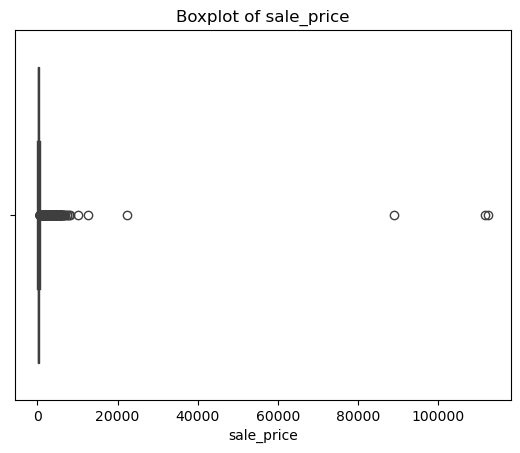

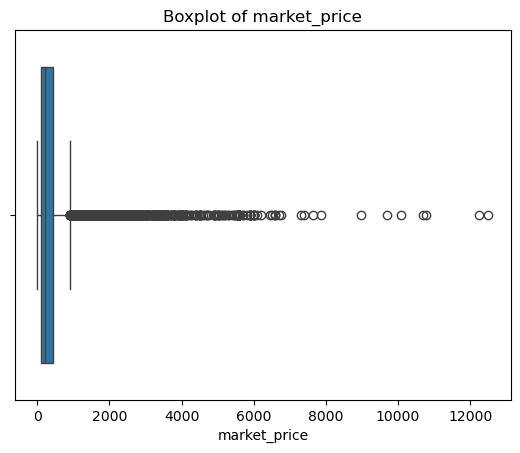

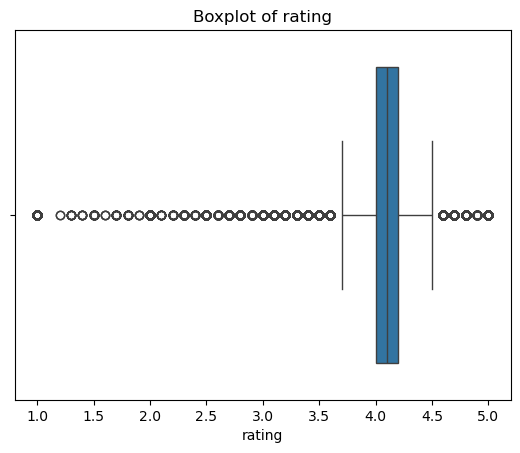

In [17]:
num_cols = ['sale_price', 'market_price', 'rating']
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [18]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"{column}: {len(outliers)} outliers")
    
for col in num_cols:
    detect_outliers(col)

sale_price: 2205 outliers
market_price: 2147 outliers
rating: 6372 outliers


In [19]:
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                         np.where(df[column] > upper_bound, upper_bound, df[column]))

for col in num_cols:
    cap_outliers(col)

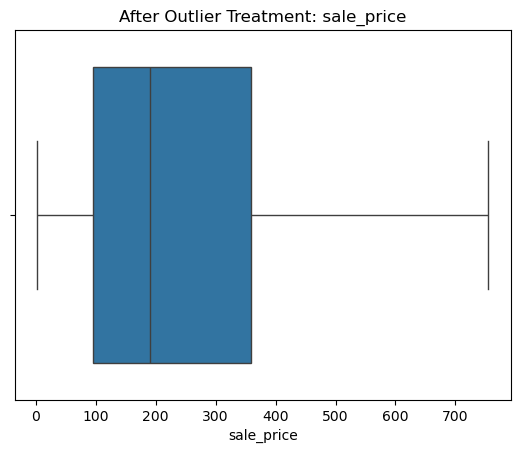

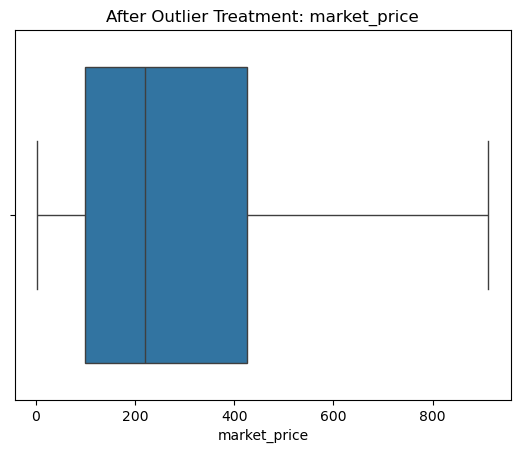

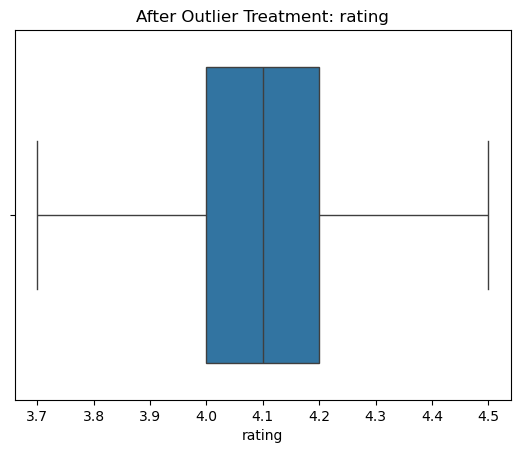

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'After Outlier Treatment: {col}')
    plt.show()

### Outlier Detection and Treatment
- Outliers were identified using the IQR (Interquartile Range) method  
- Significant outliers were observed in price-related columns such as sale_price and market_price  
- Instead of removing data, outliers were capped using lower and upper bounds  
- This approach helps retain data while reducing the impact of extreme values  

In [21]:
df['discount_amount'] = df['market_price'] - df['sale_price']

In [22]:
df['discount_percent'] = ((df['market_price'] - df['sale_price']) / df['market_price']) * 100

In [23]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description', 'discount_amount',
       'discount_percent'],
      dtype='object')

In [24]:
df.head(5)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,discount_amount,discount_percent
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...,0.0,0.000000
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,3.7,"Each product is microwave safe (without lid), ...",0.0,0.000000
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.7,"A perfect gift for all occasions, be it your m...",131.0,52.400000
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...,27.0,15.340909
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...,0.0,0.000000


- Created a new feature 'discount_amount' to calculate the price difference between market price and sale price  
- Created 'discount_percent' to understand the percentage discount offered on products  
- These features help in analyzing pricing strategies and promotional trends  

**Exploratory Data Analysis**

****1.Univariate****

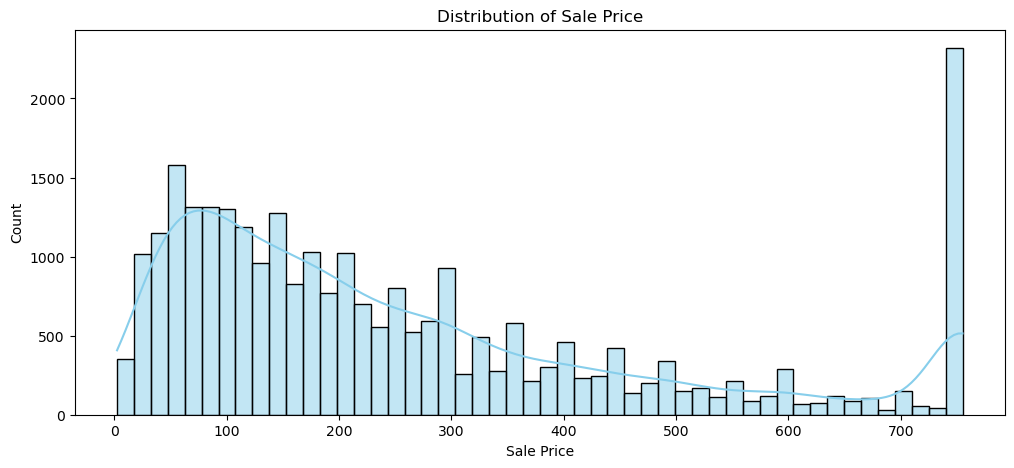

In [25]:
#sales price
plt.figure(figsize=(12,5))
sns.histplot(df['sale_price'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

- The distribution of sale price is right-skewed, indicating the presence of higher-priced products  
- Most products are concentrated in the lower price range (approximately ₹50 to ₹300)  
- A gradual decline in frequency is observed as price increases  
- Few products exist in the higher price range, showing a long tail distribution  
- The peak around lower price bins suggests that affordable products dominate the platform  

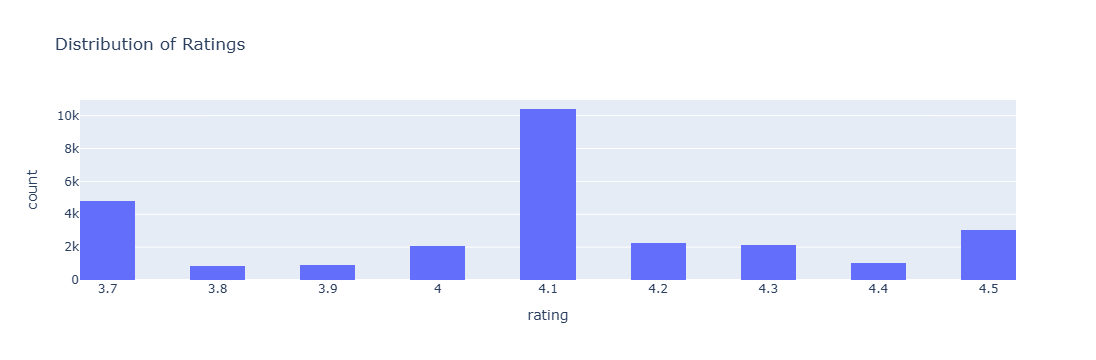

In [48]:
#ratings
fig = px.histogram(df, x='rating', nbins=30,title='Distribution of Ratings')
fig.show()

- Most product ratings are concentrated between 4.0 and 4.2, indicating generally high customer satisfaction  
- The highest frequency is observed around rating 4.1, making it the most common rating  
- Very few products have ratings below 3.8, suggesting limited poor-performing products  
- The distribution is slightly left-skewed, with more values on the higher rating side  
- Overall, the platform maintains a strong rating profile across products  

In [27]:
#df.columns

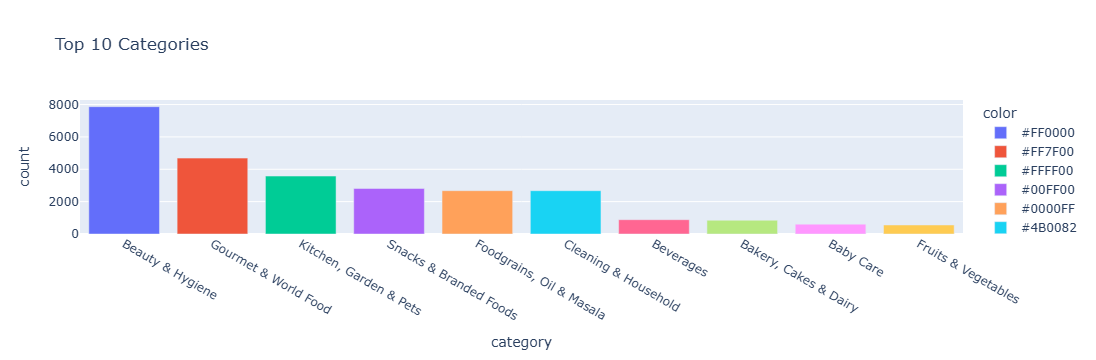

In [44]:
#cateogries
top_cat = df['category'].value_counts().head(10).reset_index()
colors=['#FF0000','#FF7F00','#FFFF00','#00FF00','#0000FF','#4B0082','#9400D3','#FF1493','#00CED1','#FFD700']
top_cat.columns = ['category', 'count']
fig = px.bar(top_cat, x='category', y='count',color=colors,title='Top 10 Categories')
fig.show()

- Beauty & Hygiene is the most dominant category with the highest number of products  
- Gourmet & World Food and Kitchen, Garden & Pets also contribute significantly to the product range  
- Categories like Snacks & Branded Foods and Foodgrains, Oil & Masala show strong presence, indicating high demand for daily essentials  
- Cleaning & Household has moderate representation, reflecting regular utility purchases  
- Categories such as Beverages, Bakery, Baby Care, and Fruits & Vegetables have comparatively fewer listings  
- The distribution suggests a stronger focus on packaged and personal care products over fresh produce  

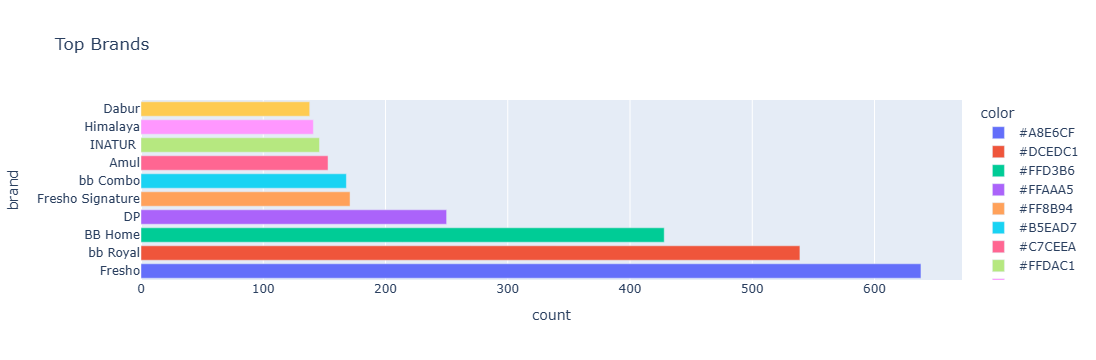

In [43]:
#brand
top_brand = df['brand'].value_counts().head(10).reset_index()
colors = ['#A8E6CF','#DCEDC1','#FFD3B6','#FFAAA5','#FF8B94','#B5EAD7','#C7CEEA','#FFDAC1','#E2F0CB','#FFB7B2']
top_brand.columns = ['brand', 'count']
fig = px.bar(top_brand, x='count', y='brand', orientation='h',color=colors,title='Top Brands')
fig.show()

- Fresho is the most dominant brand with the highest number of product listings  
- bb Royal and BB Home also have a strong presence, indicating BigBasket’s focus on in-house/private labels  
- DP shows moderate representation compared to leading brands  
- Other brands like Fresho Signature, bb Combo, Amul, and INATUR have relatively lower product counts  
- Established brands like Dabur and Himalaya are present but not as dominant in terms of product volume  
- The distribution highlights a strong emphasis on private label brands over third-party brands  

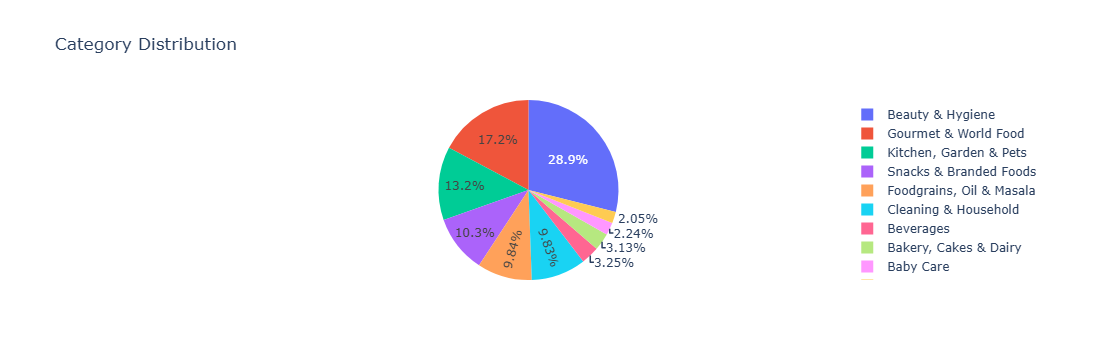

In [30]:
#category share
colors=['#A8DADC','#457B9D','#1D3557','#F1FAEE','#E63946','#FFB4A2','#6D6875','#B5838D','#84A59D','#F4A261']
fig = px.pie(top_cat, names='category', values='count',color=colors, title='Category Distribution')
fig.show()

- Beauty & Hygiene holds the largest share (~28.9%), making it the dominant category  
- Gourmet & World Food (17.2%) and Kitchen, Garden & Pets (13.2%) also contribute significantly  
- Snacks & Branded Foods and Foodgrains categories show moderate representation  
- Cleaning & Household has a noticeable but smaller share compared to top categories  
- Categories like Beverages, Bakery, Baby Care, and others contribute minimal proportions  
- The distribution indicates a stronger focus on personal care and packaged goods over niche categories  

****2.Bivariate****

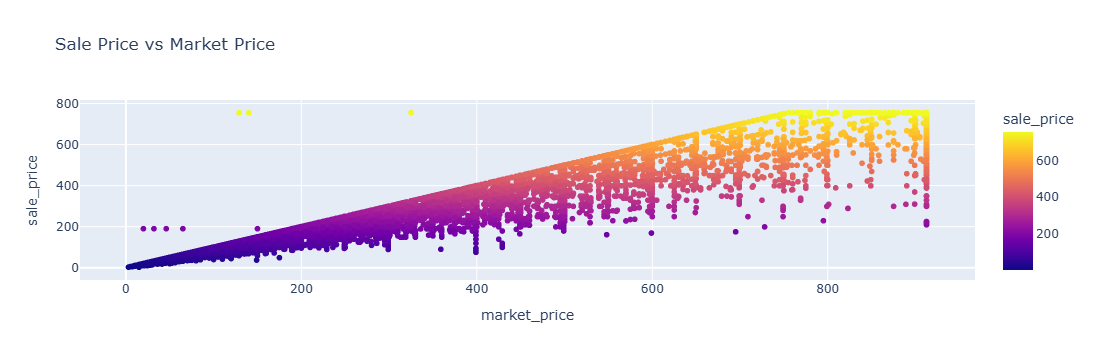

In [41]:
#sales price vs market price
fig = px.scatter(df, x='market_price', y='sale_price',color='sale_price',
                 title='Sale Price vs Market Price')
fig.show()

- A strong positive relationship is observed between market price and sale price  
- Most data points lie below the diagonal trend, indicating that products are generally sold at a discount  
- The spread increases as prices increase, suggesting higher variability in discounts for expensive products  
- A few scattered points indicate possible anomalies or products with unusual pricing patterns  
- The dense clustering in lower price ranges shows that most products are priced affordably  

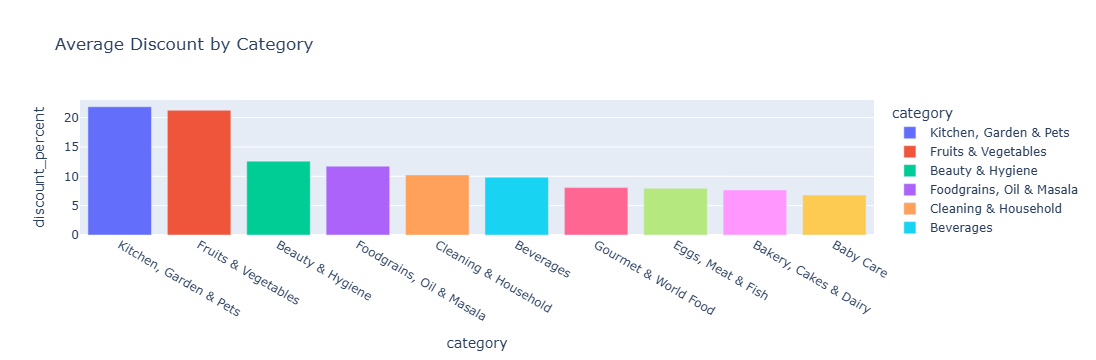

In [39]:
#discount% by category
cat_discount = df.groupby('category')['discount_percent'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(cat_discount,x='category',y='discount_percent',color='category',title='Average Discount by Category')
fig.show()

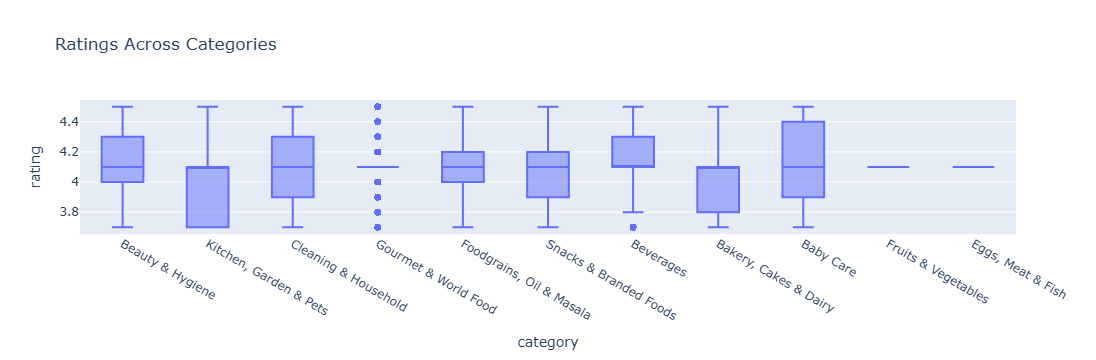

In [33]:
#rating vs discount
fig = px.box(df, x='category', y='rating',
             title='Ratings Across Categories')
fig.show()

- Ratings across most categories are consistently high, generally ranging between 4.0 and 4.3  
- Median ratings for most categories are around 4.1, indicating stable customer satisfaction  
- Categories like Beverages and Baby Care show slightly higher median ratings  
- Kitchen, Garden & Pets and Bakery categories exhibit slightly wider spread, indicating variation in customer experience  
- Presence of a few lower-end outliers suggests occasional poorly rated products  
- Overall, rating distribution is fairly uniform across categories with no major underperforming segment  

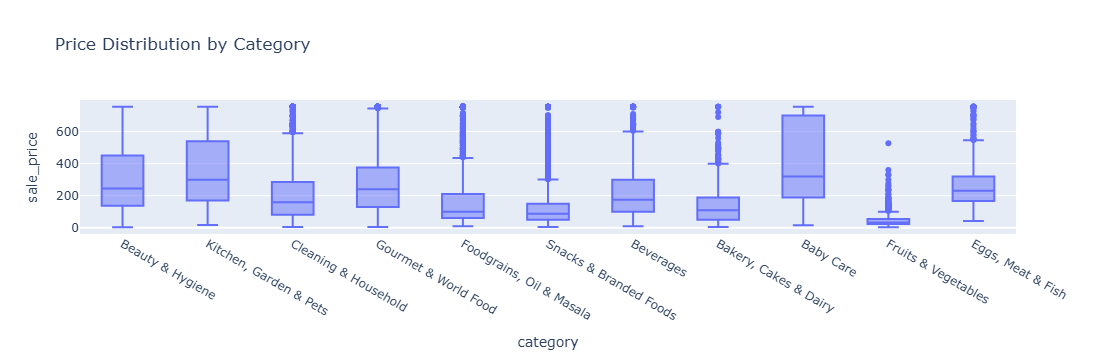

In [34]:
#sales price vs category
fig = px.box(df, x='category', y='sale_price',
             title='Price Distribution by Category')
fig.show()

- Significant variation in sale prices is observed across different categories  
- Baby Care and Kitchen, Garden & Pets show higher median prices, indicating relatively premium products  
- Categories like Fruits & Vegetables and Foodgrains have lower price ranges, reflecting everyday essentials  
- Wide interquartile ranges in some categories indicate diverse product pricing within the same category  
- Presence of multiple outliers suggests availability of premium/high-priced items across categories  
- Categories such as Snacks & Branded Foods and Bakery items have relatively lower and more concentrated price ranges  

In [35]:
df.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description', 'discount_amount',
       'discount_percent'],
      dtype='object')

****3.Multivariate****

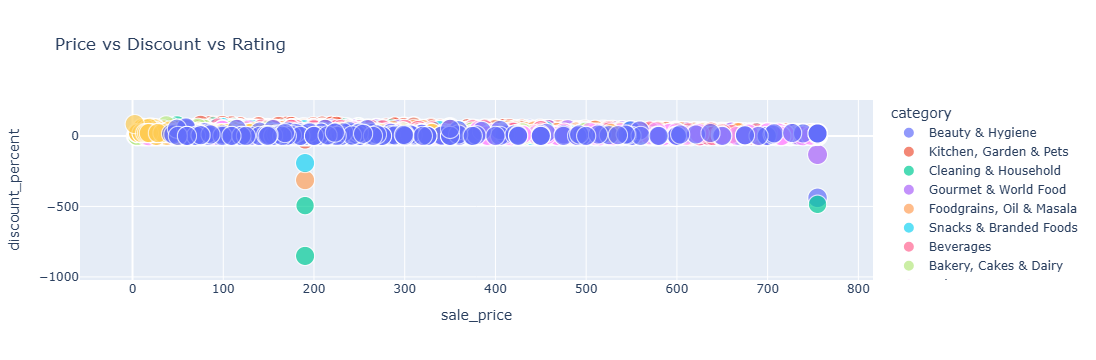

In [36]:
fig = px.scatter(df,
                 x='sale_price',
                 y='discount_percent',
                 size='rating',
                 color='category',
                 title='Price vs Discount vs Rating')
fig.show()

- Most products cluster around lower discount values, indicating moderate discounting across the platform  
- Ratings remain consistently high across different price and discount levels, showing weak correlation between discount and rating  
- Higher-priced products do not necessarily receive higher ratings, suggesting price is not a key driver of customer satisfaction  
- A few extreme negative discount values (outliers) are visible, indicating possible data inconsistencies or pricing anomalies  
- Dense clustering across categories suggests similar pricing and discount strategies across product types  

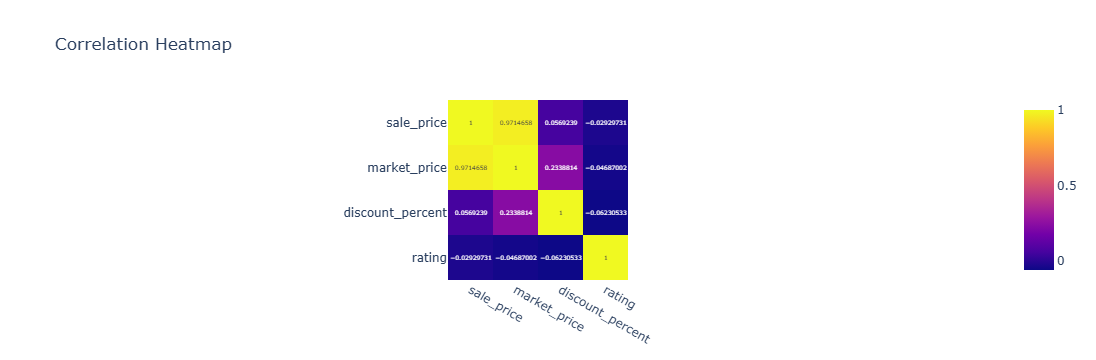

In [37]:
corr = df[['sale_price', 'market_price', 'discount_percent', 'rating']].corr()

fig = px.imshow(corr, text_auto=True, title='Correlation Heatmap')
fig.show()

- A very strong positive correlation (~0.97) exists between sale_price and market_price, indicating consistent pricing structure  
- Discount_percent shows a weak positive correlation with market_price (~0.23), suggesting higher-priced items may have slightly higher discounts  
- Sale_price has very low correlation with discount_percent, indicating discounts vary independently of selling price  
- Rating has negligible (near zero or slightly negative) correlation with price and discount features  
- This suggests that customer ratings are not significantly influenced by price or discount levels  